In [28]:
!pip install tabulate



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate

%matplotlib inline


In [30]:
df = pd.read_pickle("../assets/data/kepler_data.pkl")


In [33]:
print(tabulate(df, headers='keys', tablefmt='rst'))


========  =======  ============  ============  ========  ==========  =======  =======  =======  ======  ======  =====  ==========================================================================  =======================================================================  =======================================================================  ==========
     KIC    index        period    period_err      bjd0    bjd0_err    morph     GLon     GLat    kmag    Teff  SC     time                                                                        flux                                                                     flux_err                                                                   n_points
========  =======  ============  ============  ========  ==========  =======  =======  =======  ======  ======  =====  ==========================================================================  =======================================================================  ============================

In [34]:
print(tabulate(df, headers='keys', tablefmt='simple_grid'))


┌──────────┬─────────┬──────────────┬──────────────┬──────────┬────────────┬─────────┬─────────┬─────────┬────────┬────────┬───────┬────────────────────────────────────────────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┬────────────┐
│      KIC │   index │       period │   period_err │     bjd0 │   bjd0_err │   morph │    GLon │    GLat │   kmag │   Teff │ SC    │ time                                                                       │ flux                                                                    │ flux_err                                                                │   n_points │
├──────────┼─────────┼──────────────┼──────────────┼──────────┼────────────┼─────────┼─────────┼─────────┼────────┼────────┼───────┼────────────────────────────────────────────────────────────────────────────┼─────────────────────────────────────────────────

In [ ]:
df.index.name


'KIC'

---

In [8]:
def plotLightCurve(df, kic, with_error=True):
    if kic not in df.index:
        raise ValueError(f"KIC {kic} not found in DataFrame index.")

    row = df.loc[kic]

    t = row["time"]
    f = row["flux"]
    e = row["flux_err"]

    plt.figure(figsize=(20, 5))

    if with_error and e is not None:
        plt.errorbar(t, f, yerr=e, fmt='-', linewidth=1)
    else:
        plt.plot(t, f, linewidth=1)

    plt.xlabel("Time")
    plt.ylabel(r"Normalized Flux (e$^{-}$ s$^{-1}$)")
    plt.title(f"KIC {kic} Light Curve")
    plt.show()
    

---

In [25]:
sampleKIC = df.sample(n = 1).index[0]
sampleKIC


np.int64(6634112)

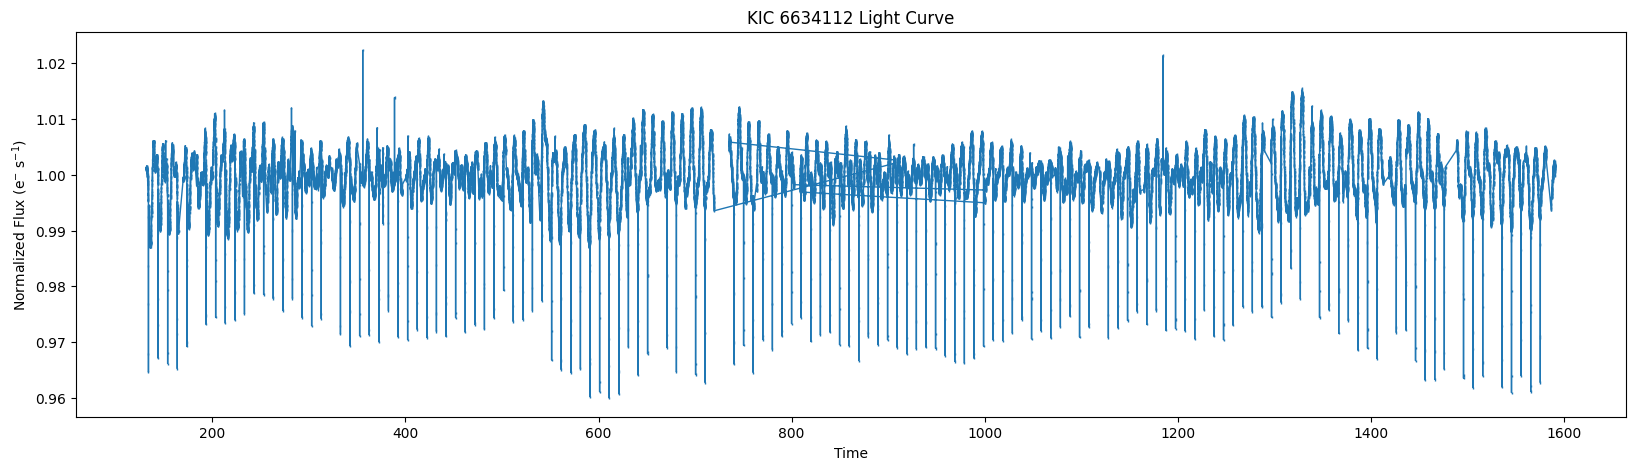

In [26]:
plotLightCurve(df, kic=sampleKIC)
